<a href="https://colab.research.google.com/github/Darwisher/BigDataGroupProject/blob/main/Bigdataproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np

# 1. Loading Data in chunks and filtering crops
chunk_size = 500000
chunks = []
target_crops = ['Wheat', 'Maize', 'Rice']
pattern = '|'.join(target_crops)

print("Starting to read and filter 1.7GB Dataset... this may take a moment.")
for chunk in pd.read_csv('Trade_DetailedTradeMatrix_E_All_Data_NOFLAG.csv', chunksize=chunk_size, encoding='latin1'):
    mask = chunk['Item'].str.contains(pattern, case=False, na=False)
    chunks.append(chunk[mask])

df_raw = pd.concat(chunks, ignore_index=True)
print("Filtering complete. Rows retrieved:", df_raw.shape[0])

# 2. Filtering Irrelevant Columns
print("Cleaning Data...")
cols_to_drop = ['Reporter Country Code', 'Reporter Country Code (M49)',
                'Partner Country Code', 'Partner Country Code (M49)',
                'Item Code', 'Item Code (CPC)', 'Element Code']
df_clean = df_raw.drop(columns=[col for col in cols_to_drop if col in df_raw.columns])

# 3. Reshaping Data
year_cols = [col for col in df_clean.columns if col.startswith('Y') and col[1:].isdigit()]
id_cols = [col for col in df_clean.columns if col not in year_cols]

df_melted = pd.melt(df_clean, id_vars=id_cols, value_vars=year_cols, var_name='Year', value_name='Value')

# 4. Final Processing
df_melted['Year'] = df_melted['Year'].str.replace('Y', '').astype(int)
df_melted = df_melted.dropna(subset=['Value'])
df_melted = df_melted.drop_duplicates()
df_melted = df_melted[df_melted['Value'] >= 0]

# 5. Save Preprocessed dataset
output_file = 'Preprocessed_Trade_Data.csv'
df_melted.to_csv(output_file, index=False)
print(f"Preprocessed dataset saved successfully to {output_file}!")


Starting to read and filter 1.7GB Dataset... this may take a moment.
Filtering complete. Rows retrieved: 326172
Cleaning Data...
Preprocessed dataset saved successfully to Preprocessed_Trade_Data.csv!


In [7]:
import csv
import re

input_file = 'Trade_DetailedTradeMatrix_E_All_Data_NOFLAG.csv'
output_file = 'Preprocessed_Trade_Data.csv'

# Drops
cols_to_drop = {'Reporter Country Code', 'Reporter Country Code (M49)',
                'Partner Country Code', 'Partner Country Code (M49)',
                'Item Code', 'Item Code (CPC)', 'Element Code'}

target_crops = ['Wheat', 'Maize', 'Rice']

def contains_target(item_str):
    item_lower = item_str.lower()
    for crop in target_crops:
        if crop.lower() in item_lower:
            return True
    return False

print("Processing massively large CSV row by row. This uses almost NO Memory (Pure Python).")

with open(input_file, mode='r', encoding='latin1') as infile, \
     open(output_file, mode='w', encoding='utf-8', newline='') as outfile:

    reader = csv.reader(infile)
    writer = csv.writer(outfile)

    # Read Header
    header = next(reader)

    # Analyze Header
    year_indices = []
    keep_indices = []
    item_idx = -1

    out_header = []

    for i, col in enumerate(header):
        if col == 'Item':
            item_idx = i

        if col.startswith('Y') and col[1:].isdigit():
            year_indices.append((i, col[1:])) # Ex: 'Y1986' -> '1986'
        elif col not in cols_to_drop:
            keep_indices.append(i)
            out_header.append(col)

    out_header.extend(['Year', 'Value'])
    writer.writerow(out_header)

    # Stream rows
    rows_processed = 0
    rows_written = 0
    seen = set() # To handle drop_duplicates

    for row in reader:
        rows_processed += 1
        if rows_processed % 1000000 == 0:
            print(f"Processed {rows_processed} rows...")

        # If pattern matches
        if len(row) > item_idx and contains_target(row[item_idx]):
            # Base info
            base_data = tuple(row[i] for i in keep_indices)

            # Melt Years
            for y_idx, year_val in year_indices:
                if y_idx < len(row):
                    val = row[y_idx]
                    # Drop Missing values and keep >= 0
                    if val.strip() != '':
                        try:
                            # Parse numeric
                            numeric_val = float(val)
                            if numeric_val >= 0:
                                # Create row fingerprint
                                out_row = base_data + (year_val, numeric_val)
                                if out_row not in seen:
                                    seen.add(out_row)
                                    writer.writerow(out_row)
                                    rows_written += 1
                        except ValueError:
                            pass # Ignored invalid values

print(f"Finished! Total Rows Scanned: {rows_processed}")
print(f"Total Rows Saved to Preprocessed Dataset: {rows_written}")
print(f"Saved directly to -> '{output_file}'")


Processing massively large CSV row by row. This uses almost NO Memory (Pure Python).
Processed 1000000 rows...
Processed 2000000 rows...
Processed 3000000 rows...
Processed 4000000 rows...
Processed 5000000 rows...
Processed 6000000 rows...
Finished! Total Rows Scanned: 6640547
Total Rows Saved to Preprocessed Dataset: 2437186
Saved directly to -> 'Preprocessed_Trade_Data.csv'


In [8]:
 #1. Dataset Gathering

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_theme(style='darkgrid')

In [12]:
import pandas as pd

#2. Loading and Pre-Processing (Raw Data EDA)
chunk_size = 500000
chunks = []
target_crops = ['Wheat', 'Maize', 'Rice']

# Define the file path
file_path = 'Trade_DetailedTradeMatrix_E_All_Data_NOFLAG.csv'

# Use regex to find elements containing our target crops
pattern = '|'.join(target_crops)

print("Loading large Data into Memory via chunks...")
for chunk in pd.read_csv(file_path, chunksize=chunk_size, encoding='latin1'):
    mask = chunk['Item'].str.contains(pattern, case=False, na=False)
    chunks.append(chunk[mask])

df_raw = pd.concat(chunks, ignore_index=True)
print('Raw Filtered Data Shape:', df_raw.shape)
df_raw.head()

Loading large Data into Memory via chunks...
Raw Filtered Data Shape: (326172, 51)


,Reporter Country Code,Reporter Country Code (M49),Reporter Countries,Partner Country Code,Partner Country Code (M49),Partner Countries,Item Code,Item Code (CPC),Item,Element Code,...,Y2015,Y2016,Y2017,Y2018,Y2019,Y2020,Y2021,Y2022,Y2023,Y2024
0,2,'004,Afghanistan,10,'036,Australia,31,'23161.02,"Rice, milled",5610,...,NaN,NaN,69.08,NaN,54.95,NaN,NaN,NaN,NaN,NaN
1,2,'004,Afghanistan,10,'036,Australia,31,'23161.02,"Rice, milled",5622,...,NaN,NaN,32.00,NaN,47.00,NaN,NaN,NaN,NaN,NaN
2,2,'004,Afghanistan,10,'036,Australia,30,'F0030,"Rice, paddy (rice milled equivalent)",5610,...,NaN,NaN,69.08,NaN,54.95,NaN,NaN,NaN,NaN,NaN
3,2,'004,Afghanistan,10,'036,Australia,30,'F0030,"Rice, paddy (rice milled equivalent)",5622,...,NaN,NaN,32.00,NaN,47.00,NaN,NaN,NaN,NaN,NaN
4,2,'004,Afghanistan,52,'031,Azerbaijan,15,'0111,Wheat,5610,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
# ### Pre-processing Exploratory Data Analysis (EDA)
# Display column info and data types
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 326172 entries, 0 to 326171
Data columns (total 51 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Reporter Country Code        326172 non-null  int64  
 1   Reporter Country Code (M49)  326172 non-null  object 
 2   Reporter Countries           326172 non-null  object 
 3   Partner Country Code         326172 non-null  int64  
 4   Partner Country Code (M49)   326172 non-null  object 
 5   Partner Countries            326172 non-null  object 
 6   Item Code                    326172 non-null  int64  
 7   Item Code (CPC)              326172 non-null  object 
 8   Item                         326172 non-null  object 
 9   Element Code                 326172 non-null  int64  
 10  Element                      326172 non-null  object 
 11  Unit                         326172 non-null  object 
 12  Y1986                        17464 non-null   float64
 13 

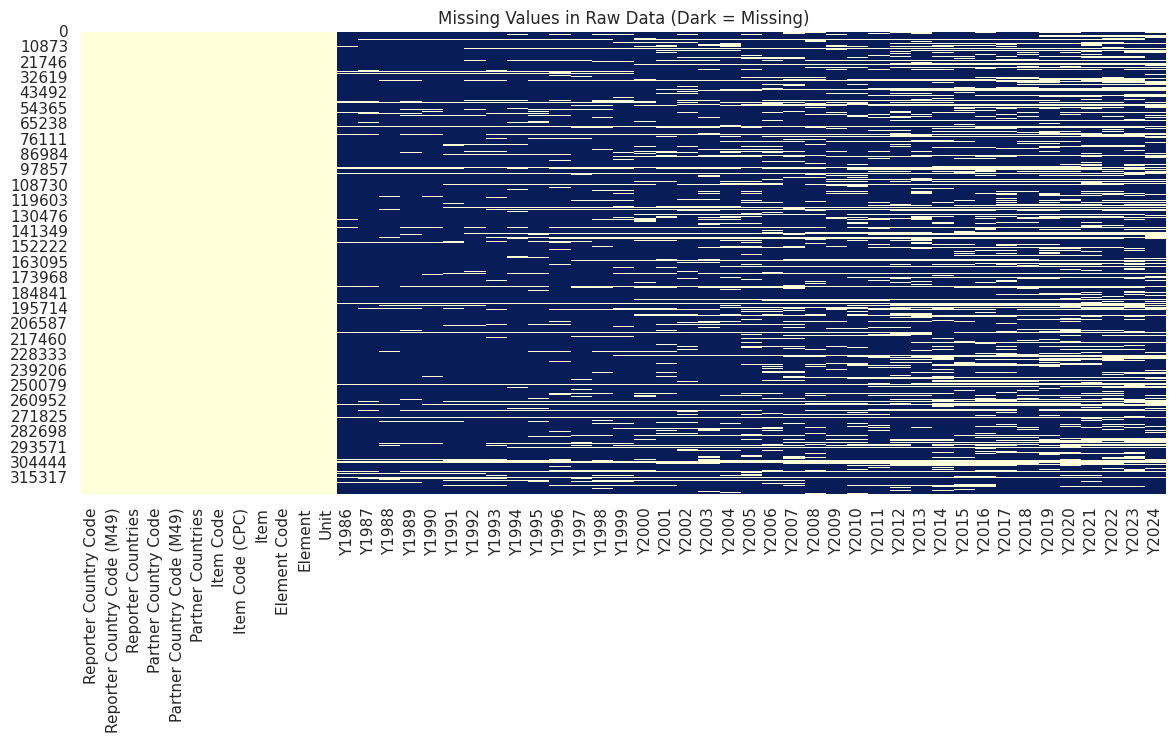

In [14]:
# Check for Missing Values across Years
plt.figure(figsize=(14, 6))
sns.heatmap(df_raw.isnull(), cbar=False, cmap='YlGnBu')
plt.title('Missing Values in Raw Data (Dark = Missing)')
plt.show()

In [15]:
# ## 3. Data Cleaning and Processing
# 1. Filter irrelevant columns
cols_to_drop = ['Reporter Country Code', 'Reporter Country Code (M49)',
                'Partner Country Code', 'Partner Country Code (M49)',
                'Item Code', 'Item Code (CPC)', 'Element Code']
df_clean = df_raw.drop(columns=[col for col in cols_to_drop if col in df_raw.columns])

# 2. Reshape: Wide to Long format
year_cols = [col for col in df_clean.columns if col.startswith('Y') and col[1:].isdigit()]
id_cols = [col for col in df_clean.columns if col not in year_cols]

df_melted = pd.melt(df_clean, id_vars=id_cols, value_vars=year_cols, var_name='Year', value_name='Value')

# Convert 'Year' to integer instead of 'Y1986'
df_melted['Year'] = df_melted['Year'].str.replace('Y', '').astype(int)

# 3. Handle Missing Values (Drop rows where Value is missing as it means no trade occurred)
df_melted = df_melted.dropna(subset=['Value'])

# 4. Remove Duplicates
df_melted = df_melted.drop_duplicates()

# Optional: Quick check for any impossible negative physical quantities/values
df_melted = df_melted[df_melted['Value'] >= 0]

print("Cleaned and Melted Data Shape:", df_melted.shape)
df_melted.head()

Cleaned and Melted Data Shape: (2437186, 7)


,Reporter Countries,Partner Countries,Item,Element,Unit,Year,Value
1248,Algeria,Albania,Wheat and meslin flour,Import quantity,t,1986,1200.0
1249,Algeria,Albania,Wheat and meslin flour,Import value,1000 USD,1986,266.0
1254,Algeria,Argentina,Maize (corn),Import quantity,t,1986,358269.0
1255,Algeria,Argentina,Maize (corn),Import value,1000 USD,1986,46565.0
1346,Algeria,Canada,Wheat,Import quantity,t,1986,389118.0


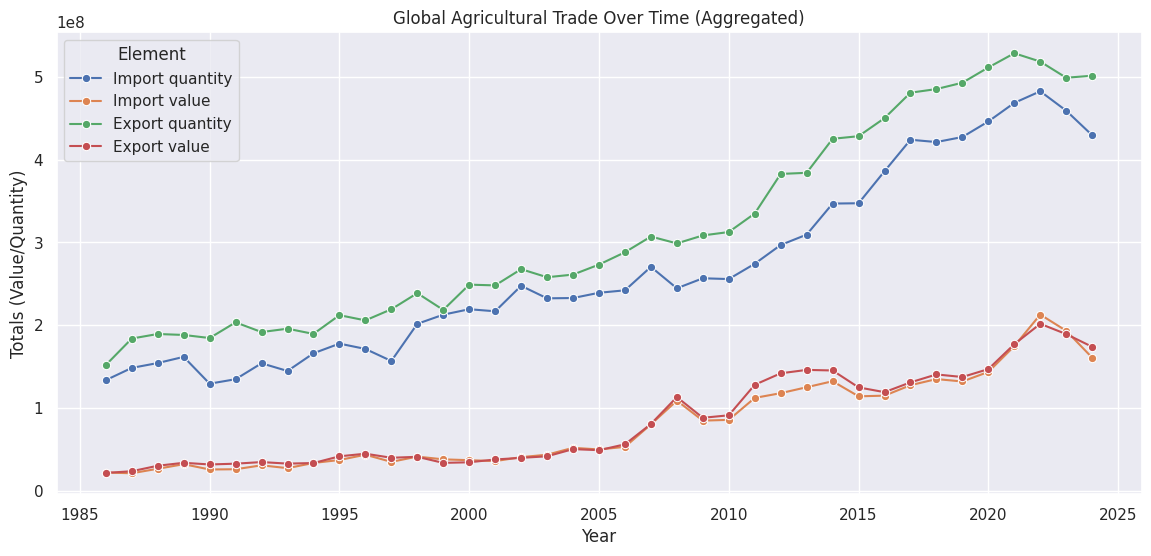

In [16]:
# ## 4. Post-Preprocessing EDA
# 1. Trade Value Trends Over Time
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_melted, x='Year', y='Value', hue='Element', estimator=sum, errorbar=None, marker="o")
plt.title('Global Agricultural Trade Over Time (Aggregated)')
plt.ylabel('Totals (Value/Quantity)')
plt.xlabel('Year')
plt.show()

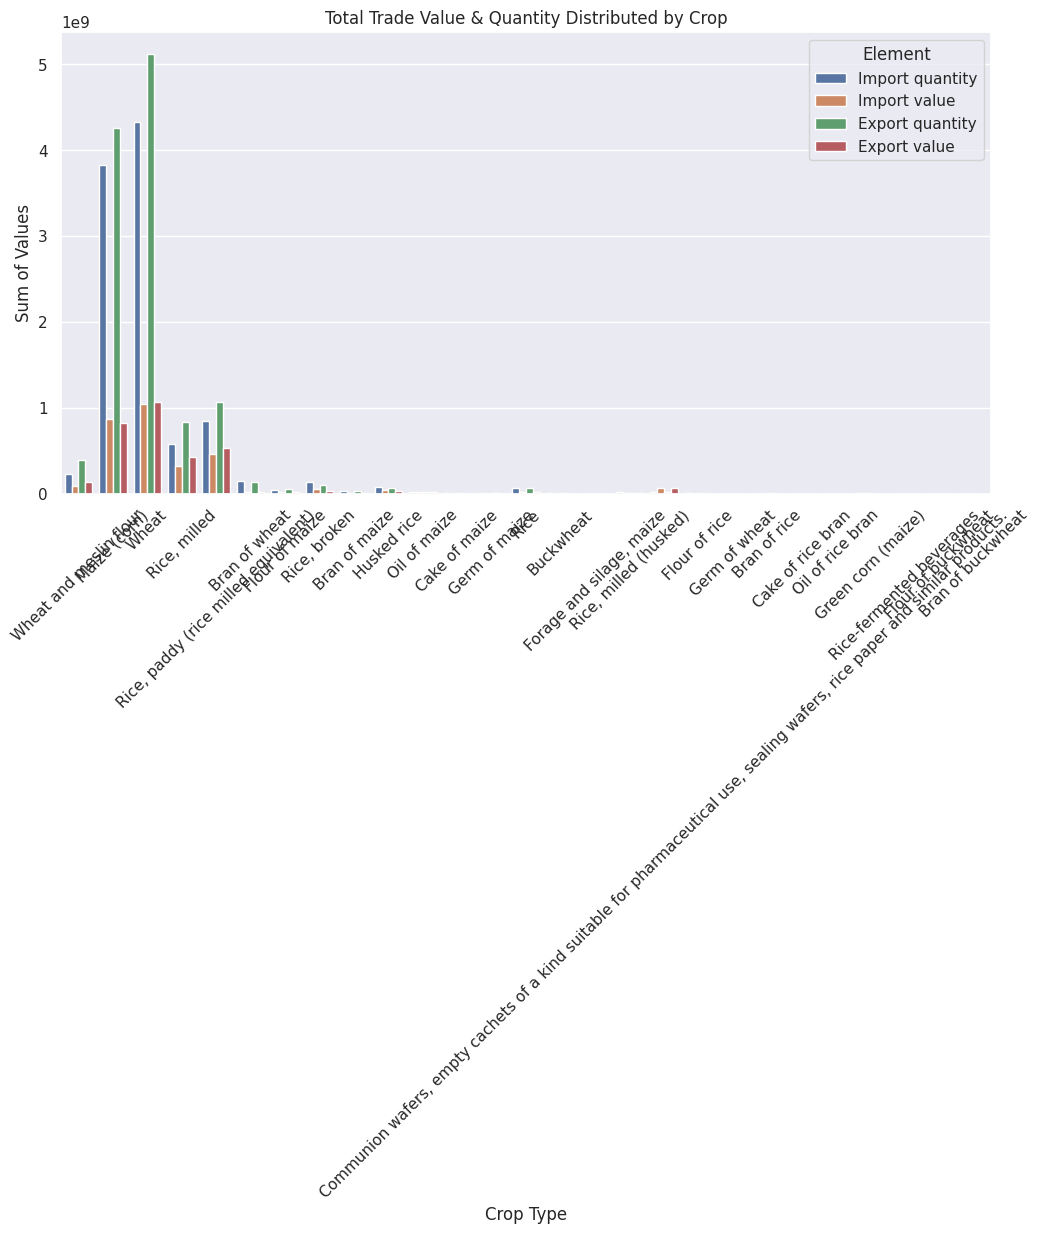

In [20]:
# 2. Distribution of Trade by Top Crops
plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Item', y='Value', hue='Element', estimator=sum, errorbar=None)
plt.title('Total Trade Value & Quantity Distributed by Crop')
plt.ylabel('Sum of Values')
plt.xlabel('Crop Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

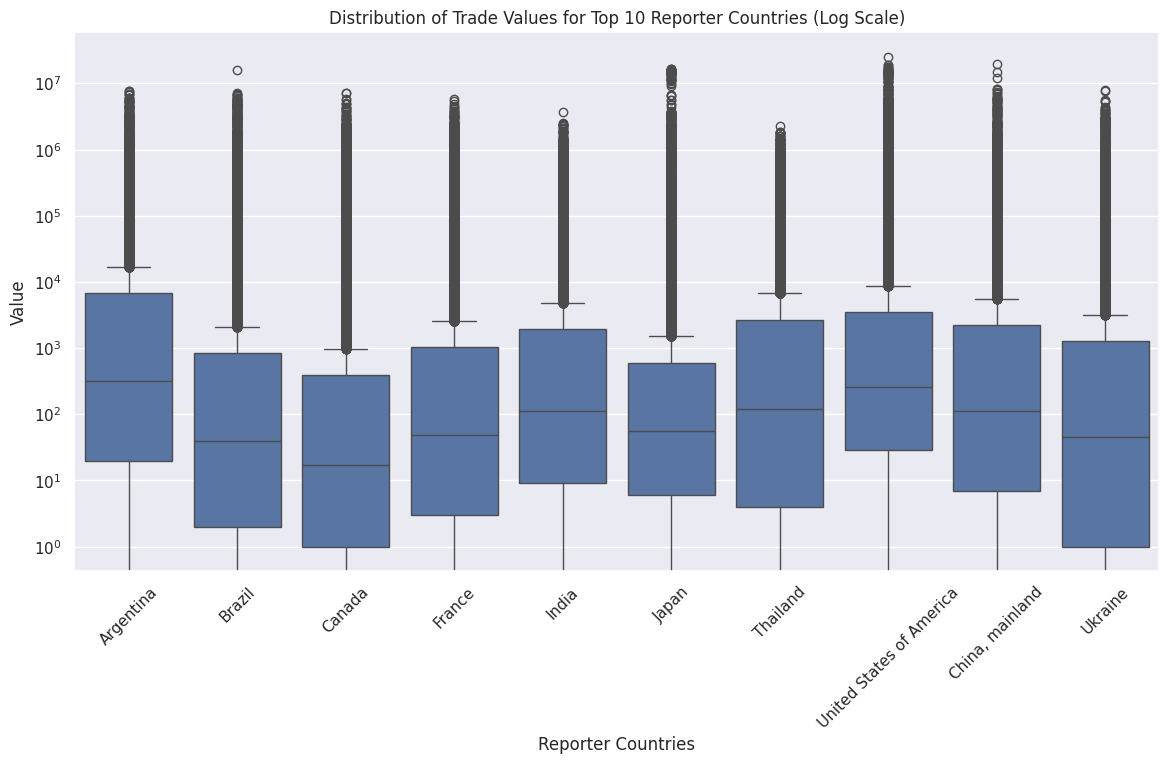

In [19]:
# 3. Filter top 10 Reporter Countries by volume to see who exports/imports the most
top_reporters = df_melted.groupby('Reporter Countries')['Value'].sum().sort_values(ascending=False).head(10).index
df_top_reporters = df_melted[df_melted['Reporter Countries'].isin(top_reporters)]

plt.figure(figsize=(14, 7))
sns.boxplot(data=df_top_reporters, x='Reporter Countries', y='Value')
plt.yscale('log') # Log scale due to large outliers
plt.title('Distribution of Trade Values for Top 10 Reporter Countries (Log Scale)')
plt.xticks(rotation=45)
plt.show()

In [17]:
# ## 5. Exporting Preprocessed Data

In [18]:
df_melted.to_csv('Preprocessed_Trade_Data.csv', index=False)
print("Successfully saved -> 'Preprocessed_Trade_Data.csv'")

Successfully saved -> 'Preprocessed_Trade_Data.csv'
